# Data Visualization
EDA: exploratory data analysis
1. Compute summary stats
1. Generate data visualizations

## Goals of Data Vis
1. Clearly and accurately represent data
1. Be creative, with the goal of increading readability
1. Label units, axes, and points of interests

## Some Jargon
Chart: 2D visualization
* Plot: a chart of data points (e.g. scatter plot)
* Graph: a chart of a mathematical function (e.g. sine curve)

## Ways to use Matplotlib
1. Use the pyplot module: like a state machine (e.g. there is always a "current figure")
1. Use the OOP interface: maintain object references
1. Mix of the two

# Matplotlib Chart Examples
## Line Chart Example

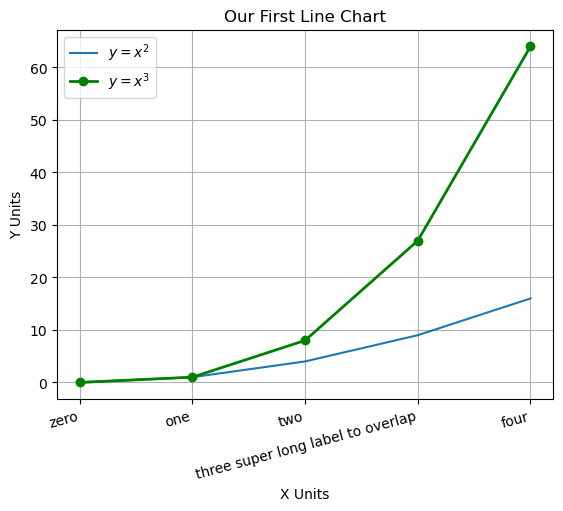

In [6]:
import matplotlib.pyplot as plt 

def line_chart_example(x, y2, y3):
    plt.figure() # create a new "current figure"
    plt.plot(x, y2, label="$y=x^2$")
    plt.plot(x, y3, c="green", lw=2, marker='o', label="$y=x^3$")
    # add some labels
    plt.legend()
    plt.title("Our First Line Chart")
    plt.xlabel("X Units")
    plt.ylabel("Y Units")
    plt.grid(True)
    # customize the x tick locations and labels
    xtick_labels = ["zero", "one", "two", "three super long label to overlap", "four"]
    plt.xticks(x, xtick_labels, rotation=15, ha="right")
    plt.show()

# we need some data
x = list(range(5))
y2 = [val ** 2 for val in x]
# task: add another to the figure for y = x^3

y3 = [val ** 3 for val in x]
line_chart_example(x, y2, y3)





## Scatter Charts
Plus saving a chart to a file (e.g. PDF, PNG, etc.)

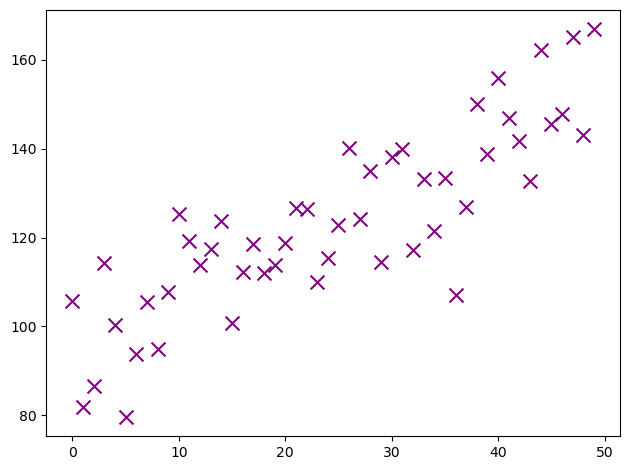

In [7]:
import numpy as np

def scatter_chart_example(x, y):
    plt.figure() # make a new current figure
    plt.scatter(x, y, marker="x", s=100, c="purple")

    # you can save a figure to a file
    plt.tight_layout() # nice function to call right before rendering
    plt.savefig("scatter_chart.pdf")
    plt.show()
    
# we need data    
x = list(range(50))
y = [np.random.normal(100, 10) + value for value in x]
scatter_chart_example(x, y)

## Bar Charts

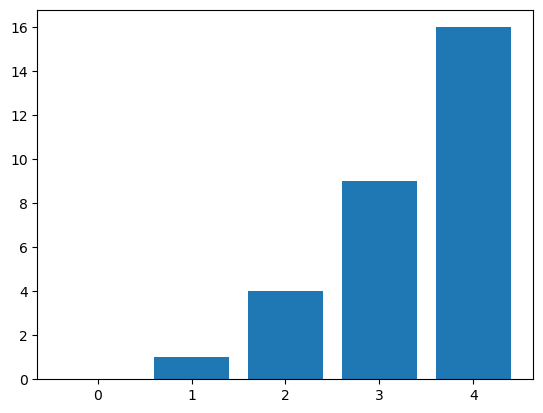

In [8]:
def bar_chart_example(x, y):
    plt.figure()
    plt.bar(x, y)
    plt.show()
    
# back to y=x^2
x = list(range(5))
y = [value ** 2 for value in x]
bar_chart_example(x, y)

## Pie Charts

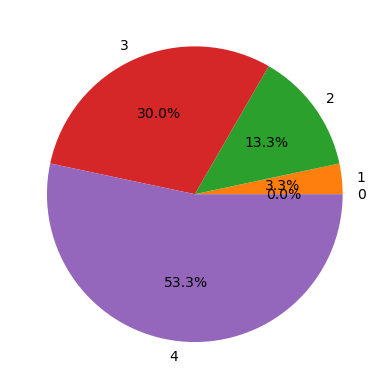

In [9]:
def pie_chart_example(x, y):
    plt.figure()
    plt.pie(y, labels=x, autopct="%1.1f%%")
    plt.show()
    
pie_chart_example(x, y)

## Histograms

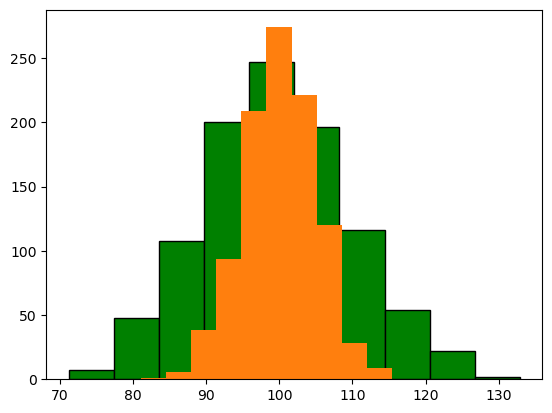

In [11]:
def histogram_example(data, data2):
    # data is a 1D list of data values
    plt.figure()
    plt.hist(data, bins=10, facecolor="green", edgecolor="black") # default is 10
    plt.hist(data2, bins=10) # default is 10
    plt.show()
    
# let's generate some random "normal" data
mean = 100 # mu
stdev = 10 # sigma 
num_samples = 1000 
normal_data = np.random.normal(mean, stdev, num_samples)
normal_data2 = np.random.normal(mean, stdev / 2, num_samples)
histogram_example(normal_data, normal_data2)

## Task 1:

1. In utils.py, write a function called get_column(table, header, col_name) that returns a column in the table.
    * Find the index of the column by looking up col_name's position in header
    * Test your function by getting the "MSRP" column from the table below
    * ```
      msrp_header = ["CarName", "ModelYear", "MSRP"]
      msrp_table = [["ford pinto", 75, 2769],
            ["toyota corolla", 75, 2711],
            ["ford pinto", 76, 3025],
            ["toyota corolla", 77, 2789]]
            ```
3. In utils.py, write a function that returns the frequencies (occurrence counts) of values for a table's (categorical) attribute.
    * Example: The call `get_frequencies(msrp_table, msrp_header, "ModelYear")` for the `msrp_table` and `msrp_header`

      should return the parallel arrays: `[75, 76, 77]` and `[2, 1, 1]`
    * Note: It would be good to add a few more rows to `msrp_table` for testing
    * Then, create a bar and a pie chart for the model year counts
      


[75, 76, 77]
[2, 1, 1]


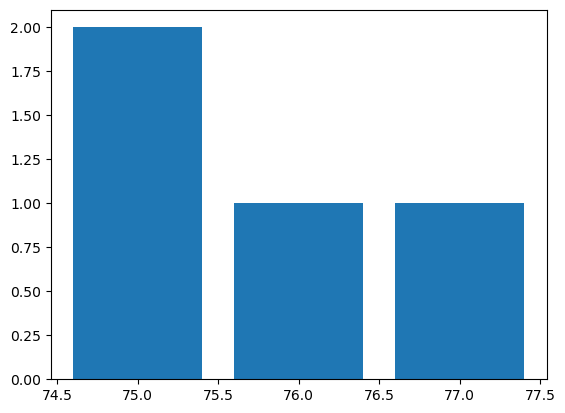

In [21]:
import utils
import importlib
importlib.reload(utils)

msrp_header = ["CarName", "ModelYear", "MSRP"]
msrp_table = [["ford pinto", 75, 2769],
            ["toyota corolla", 75, 2711],
            ["ford pinto", 76, 3025],
            ["toyota corolla", 77, 2789]]
modelyear_values, modelyear_counts = utils.get_frequencies(msrp_table, msrp_header, "ModelYear")
#print(modelyear_values)
print(modelyear_counts)
bar_chart_example(modelyear_values, modelyear_counts)


# Box Plots

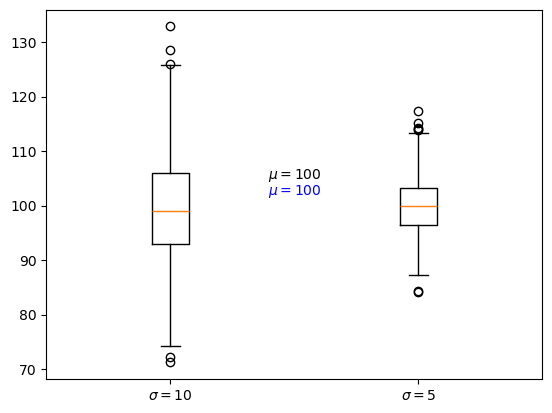

In [13]:
def box_plot_example(distributions, labels): # distributions and labels are parallel
    # distributions: list of 1D lists of values
    plt.figure()
    plt.boxplot(distributions, tick_labels=labels)
    # boxes correspond to the 1st and 3rd quartiles
    # line in the middle of the box corresponds to the 2nd quartile (AKA median)
    # whiskers corresponds to +/- 1.5 * IQR
    # IQR: interquartile range (3rd quartile - 1st quartile)
    # circles outside the whiskers correspond to outliers
    
    # annotations
    # we want to add "mu=100" to the center of our figure
    # xycoords="data": default,specify the label location using x and y data values
    # xycoords = "axes fraction": specify the location of the label in absolute
    # axes coordinates... 0,0 is the lower left corner, 1,1 is the upper right corner
    # coordinates as the plotted data
    plt.annotate(r"$\mu=100$", xy=(1.5, 105), xycoords="data", horizontalalignment="center")
    plt.annotate(r"$\mu=100$", xy=(0.5, 0.5), xycoords="axes fraction", 
                 horizontalalignment="center", color="blue")

    plt.show()
    
normal_data2 = np.random.normal(mean, stdev / 2, num_samples)
box_plot_example([normal_data, normal_data2], [r"$\sigma=10$", r"$\sigma=5$"])

## Group By Task2
* In utils.py, write a group_by() function that takes a table, header, and column name, partitions the rows based on the values in that column, and returns the unique group values and the corresponding subtables.
* Test your function on ModelYear attribute
    * It would be good to add a few more rows to msrp_table for testing
* Visualize the data with model year on the x-axis, MSRP on the y-axis, and one box and whisker for each model year

In [8]:
importlib.reload(utils)
msrp_header = ["CarName", "ModelYear", "MSRP"]
msrp_table = [["ford pinto", 75, 2769],
            ["toyota corolla", 75, 2711],
            ["ford pinto", 76, 3025],
            ["ford pinto", 76, 3025],
            ["ford pinto", 76, 3025],
            ["ford pinto", 76, 3025],
            ["toyota corolla", 77, 2789]]
modelyear_names, modelyear_subtables = utils.group_by(msrp_table, msrp_header, "ModelYear")
print(modelyear_names)
print(modelyear_subtables)

[75, 76, 77]
[[['ford pinto', 75, 2769], ['toyota corolla', 75, 2711]], [['ford pinto', 76, 3025], ['ford pinto', 76, 3025], ['ford pinto', 76, 3025], ['ford pinto', 76, 3025]], [['toyota corolla', 77, 2789]]]


In [5]:
from scipy import stats
import importlib 
import utils
import numpy as np

importlib.reload(utils)
np.random.seed(0)

x = list(range(0, 100))
y = [value * 2 + np.random.normal(0, 25) for value in x]

m, b =  utils.compute_slope_intercept(x, y)
print(m, b)

# compare with scipy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html
lr_res = stats.linregress(x, y)
assert np.isclose(m, lr_res.slope)
assert np.isclose(b, lr_res.intercept)

1.9249174584304438 5.211786196055158
